         time  tavg  tmin  tmax  prcp
0  01-01-1990  23.2  17.0   NaN   0.0
1  02-01-1990  22.2  16.5  29.9   0.0
2  03-01-1990  21.8  16.3  30.7   0.0
3  04-01-1990  25.4  17.9  31.8   0.0
4  05-01-1990  26.5  19.3  33.7   0.0

Null Values:

time    0
tavg    0
tmin    0
tmax    0
prcp    0
Year    0
dtype: int64

Dataset Shape: (11894, 6)

Average Temperature By Year:

{'1990': 27.076944444444443, '1991': 26.93379120879121, '1992': 27.109836065573774, '1993': 27.175549450549454, '1994': 26.939118457300275, '1995': 27.254395604395604, '1996': 27.636612021857925, '1997': 27.657808219178083, '1998': 27.746575342465754, '1999': 27.651373626373626, '2000': 27.609016393442623, '2001': 27.256438356164384, '2002': 27.81945205479452, '2003': 27.463287671232877, '2004': 27.003005464480875, '2005': 27.358082191780824, '2006': 27.35561643835616, '2007': 28.023835616438358, '2008': 27.748360655737702, '2009': 28.33479452054795, '2010': 28.16191780821918, '2011': 27.938082191780822, '2012': 27.605

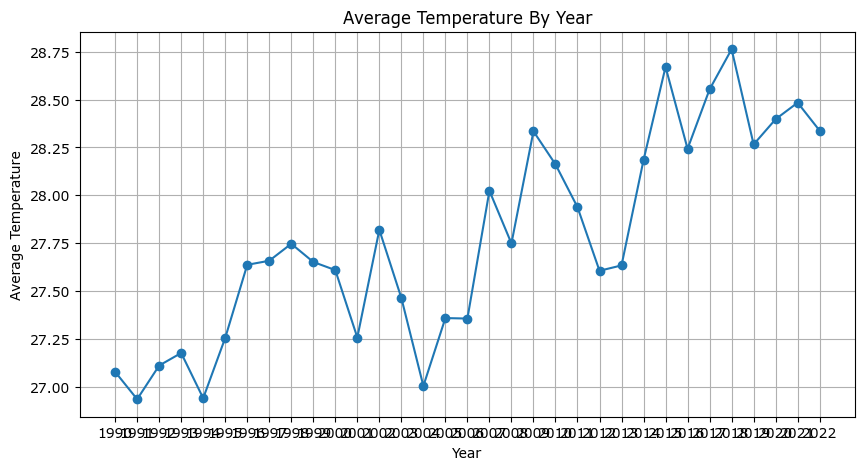

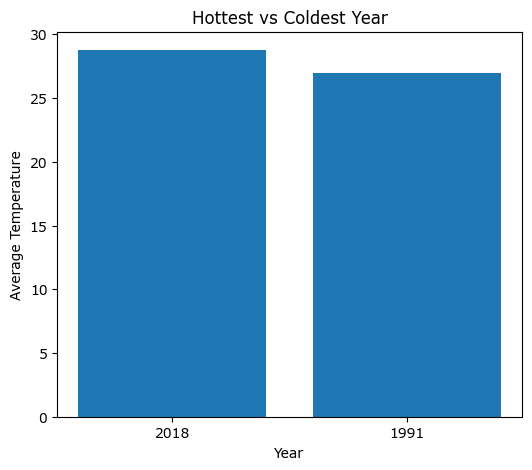

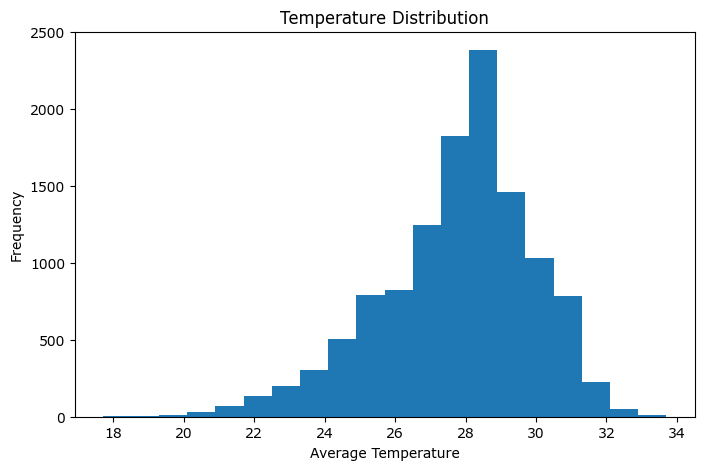

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('mumbai_weather.csv')

print(df.head())

# Fill missing average temperature
df['tavg'] = df['tavg'].fillna((df['tmin'] + df['tmax']) / 2)

# Extract Year
df['Year'] = df['time'].apply(lambda x: x.split('-')[2])

# Fill remaining missing values
df['tavg'] = df.groupby('Year')['tavg'].transform(lambda x: x.fillna(x.mean()))
df['tmin'] = df['tmin'].fillna(df['tavg'] - 5)
df['tmax'] = df['tmax'].fillna(df['tavg'] + 5)
df['prcp'] = df['prcp'].fillna(0)

print("\nNull Values:\n")
print(df.isnull().sum())

print("\nDataset Shape:", df.shape)

# ---------------- MAP FUNCTION ----------------
def mapper(df):
    result = []

    for _, row in df.iterrows():
        year = row['Year']
        tavg = row['tavg']
        result.append((year, tavg))

    return result

mapped_output = mapper(df)

# ---------------- REDUCE FUNCTION ----------------
def reducer(mapped_output):
    grouped = {}

    for year, tavg in mapped_output:
        if year in grouped:
            grouped[year].append(tavg)
        else:
            grouped[year] = [tavg]

    avg_by_year = {
        year: sum(tavgs) / len(tavgs)
        for year, tavgs in grouped.items()
    }

    return avg_by_year

reducer_output = reducer(mapped_output)

print("\nAverage Temperature By Year:\n")
print(reducer_output)

# ---------------- HOTTEST & COLDEST YEAR ----------------
hottest_year = max(reducer_output, key=reducer_output.get)
coldest_year = min(reducer_output, key=reducer_output.get)

print("\nHottest year:", hottest_year,
      "with avg temp =", reducer_output[hottest_year])

print("Coldest year:", coldest_year,
      "with avg temp =", reducer_output[coldest_year])

# =========================================================
# GRAPH 1 : Average Temperature By Year
# =========================================================

years = list(reducer_output.keys())
temps = list(reducer_output.values())

plt.figure(figsize=(10, 5))
plt.plot(years, temps, marker='o')
plt.title("Average Temperature By Year")
plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.grid(True)
plt.show()

# =========================================================
# GRAPH 2 : Hottest vs Coldest Year
# =========================================================

plt.figure(figsize=(6, 5))

plt.bar(
    [hottest_year, coldest_year],
    [reducer_output[hottest_year], reducer_output[coldest_year]]
)

plt.title("Hottest vs Coldest Year")
plt.xlabel("Year")
plt.ylabel("Average Temperature")

plt.show()

# =========================================================
# GRAPH 3 : Temperature Distribution
# =========================================================

plt.figure(figsize=(8, 5))
plt.hist(df['tavg'], bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Average Temperature")
plt.ylabel("Frequency")
plt.show()